# 03 · Order Agent Optimizations

## 🎯 Goal

Solve the same Order request four ways, then compare the traces. Nothing here
changes the customer task—the architecture is the only variable.

## 🧰 Setup

We import the small pieces used in this comparison.

In [1]:
import helper
helper.setup()

from google.adk.agents import Agent
from google.adk.skills import load_skill_from_dir
from google.adk.tools.skill_toolset import SkillToolset
from workshop import (
    MODEL,
    ORDER_SKILL,
    close_mcp_tools,
    get_order,
    list_orders,
    order_code_from_mcp,
    order_tools_from_mcp,
    run_agent,
    setup_workshop,
    show_comparison,
    show_skill,
    show_source,
    show_text,
)

workshop = setup_workshop("order-agent-optimizations")

✅ Workshop ready · Gemini configured · Phoenix tracing enabled


## Scenario

Every path receives the same request and the same grounding instruction, so
the comparison isolates architecture rather than customer intent.

In [2]:
ORDER_PROMPT = (
    "Find my most recent order from July 1 through July 31, 2026. "
    "Tell me its status, total, and every item's name and quantity."
)
BASE_INSTRUCTION = (
    "Help customers answer order questions using the available tools. "
    "Use only returned information, and clearly say when information is missing."
)
show_text("Customer request", ORDER_PROMPT)
show_text("System instruction", BASE_INSTRUCTION)

╭─────────────────────────────────────────────── Customer request ────────────────────────────────────────────────╮
│ Find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name   │
│ and quantity.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── System instruction ───────────────────────────────────────────────╮
│ Help customers answer order questions using the available tools. Use only returned information, and clearly say │
│ when information is missing.                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 1 · Local Python tools

This is the baseline from Notebook 02. The agent receives two ordinary Python
functions before we introduce MCP. ▶️ Run the shared request.

In [3]:
# Build the local baseline with the two focused Order procedures.
local_agent = Agent(
    name="local_order_agent",
    model=MODEL,
    instruction=BASE_INSTRUCTION,
    tools=[list_orders, get_order],
)
local_result = await run_agent(
    local_agent,
    ORDER_PROMPT,
    session_id="03-a-local-tools",
    trace_name="03-a-order-local-tools",
)

Your most recent order between July 1 and July 31, 2026, is order **WM-DEMO-1004**, placed on July 19, 2026.

**Order Details:**
*   **Status:** processing
*   **Total:** $291.00

**Items:**
*   **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology -White**: 1
*   **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A**: 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/98beca090a6470e353b82e54c08a0c44)

## Inspect

One familiar path is complete. The run above displays its exact Phoenix trace;
now we change only how tools are supplied.

#### 🔎 Local tools: complete flow

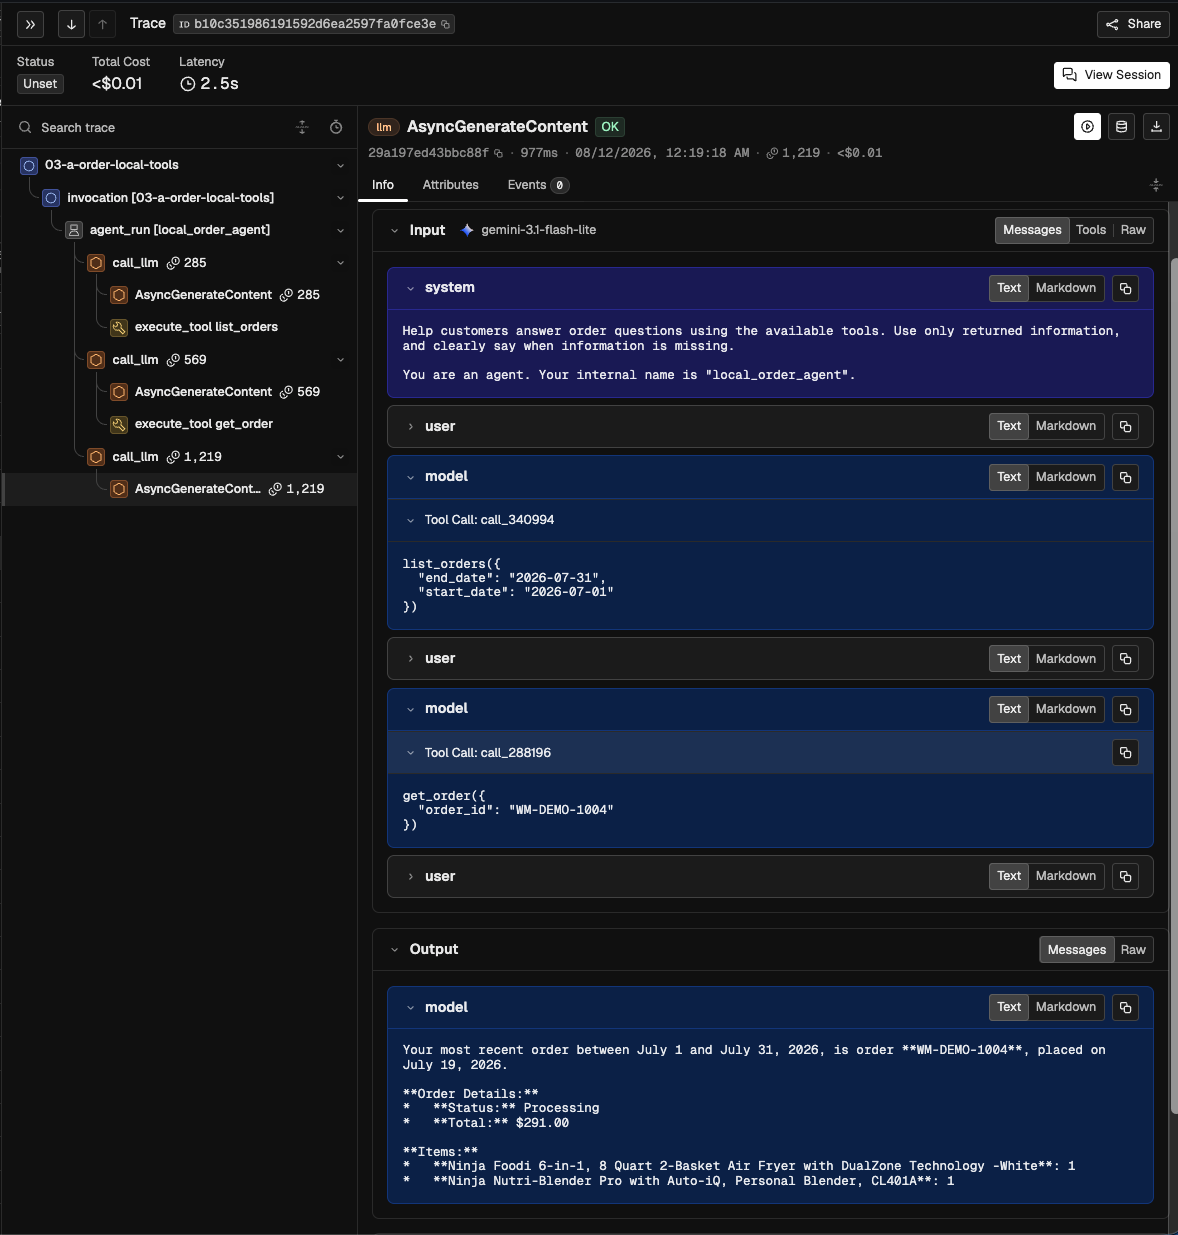

**What to notice**

The trace has three model calls and two tool calls: choose `list_orders`, choose `get_order`, then answer from the returned details.

**Takeaway:** This is the reference workflow; the next designs should solve the same request without changing its meaning.

#### 🔎 Local tools: compact definitions

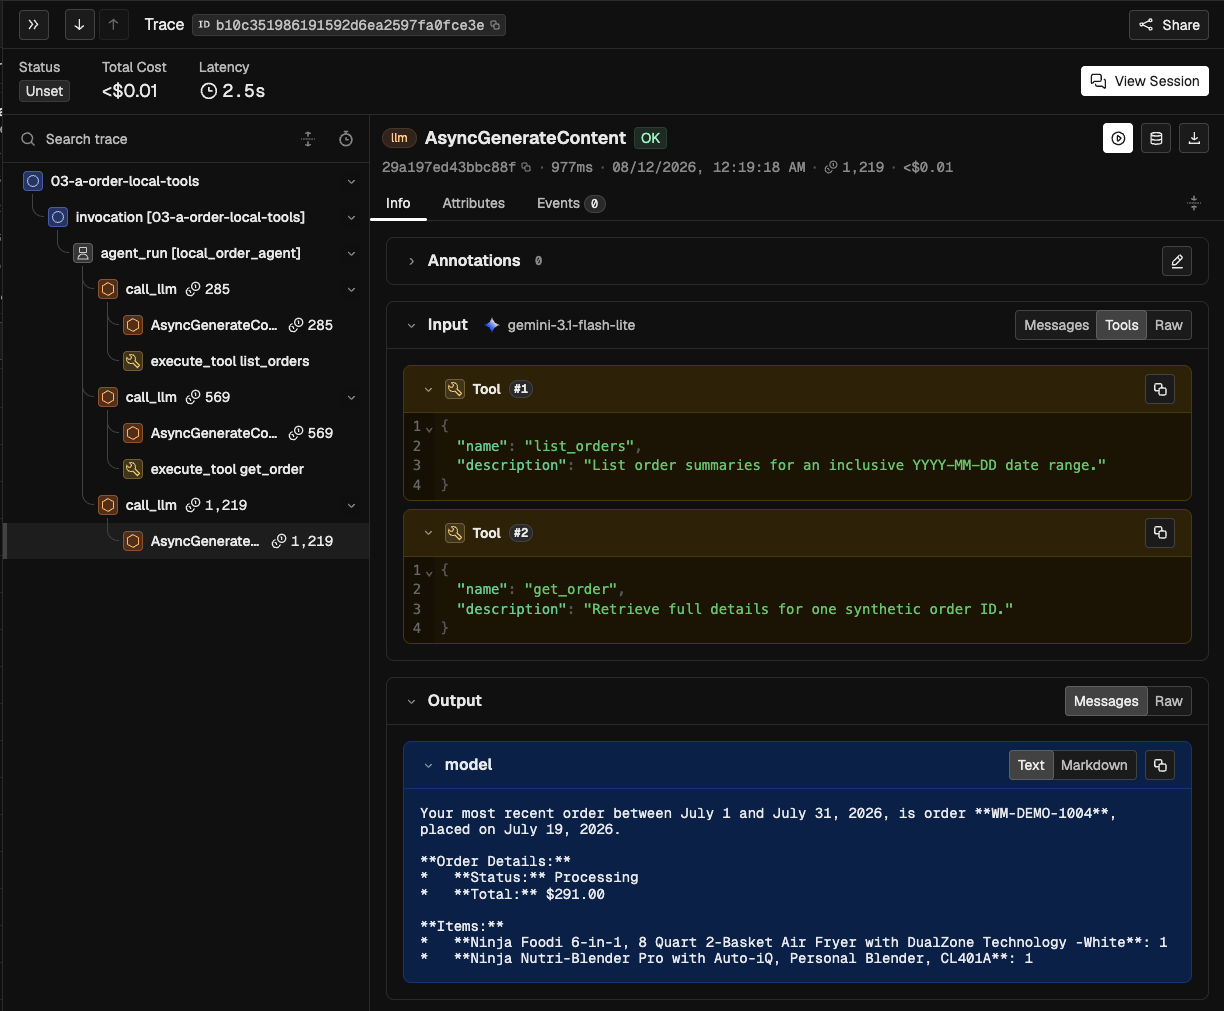

**What to notice**

The model sees two compact Python-tool definitions. In this captured run, the three model calls used 285, 569, and 1,219 tokens.

**Takeaway:** Small tool contracts leave more of the context window available for the customer's work.

## 2 · Direct MCP tools

MCP lets the server publish tool names, descriptions, input schemas, and calls.
The server advertises broader ecommerce capabilities, including Product and
Order tools; `tool_filter` exposes only the two Order tools to this agent.

In [4]:
# Activate only the tools this Order agent needs from the broader catalog.
mcp_order_tools = order_tools_from_mcp()
show_source(order_tools_from_mcp)

def order_tools_from_mcp():                                                                                        
    """Connect to only the two Order tools published by the MCP server."""                                         
                                                                                                                   
    from google.adk.tools.mcp_tool import (                                                                        
        McpToolset,                                                                                                
        StreamableHTTPConnectionParams,                                                                            
    )                                                                                                              
                                                                                                                   
    toolset = McpToolset(                                                                                          
        connection_params=StreamableHTTPConnectionParams(url=MCP_ENDPOINT),                                        
        tool_filter=["list_orders", "get_order"],                                                                  
    )                                                                                                              
    _active_toolsets.append(toolset)                                                                               
    return toolset

The helper source makes the connection boundary explicit:

```python
McpToolset(
    connection_params=StreamableHTTPConnectionParams(url=MCP_ENDPOINT),
    tool_filter=["list_orders", "get_order"],
)
```

In [5]:
# Build the agent around the filtered MCP toolset.
direct_mcp_agent = Agent(
    name="direct_mcp_order_agent",
    model=MODEL,
    instruction=BASE_INSTRUCTION,
    tools=[mcp_order_tools],
)
direct_mcp_result = await run_agent(
    direct_mcp_agent,
    ORDER_PROMPT,
    session_id="03-b-direct-mcp",
    trace_name="03-b-order-direct-mcp",
)

Your most recent order from July 2026 is **WM-DEMO-1004**, placed on July 19, 2026.

*   **Status:** processing
*   **Total:** 291.00 USD

**Items in this order:**
*   **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology -White**: 1
*   **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A**: 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/d99b7f344bd2b90dac19b7aa82b4cb83)

#### 🔎 Direct MCP: same workflow

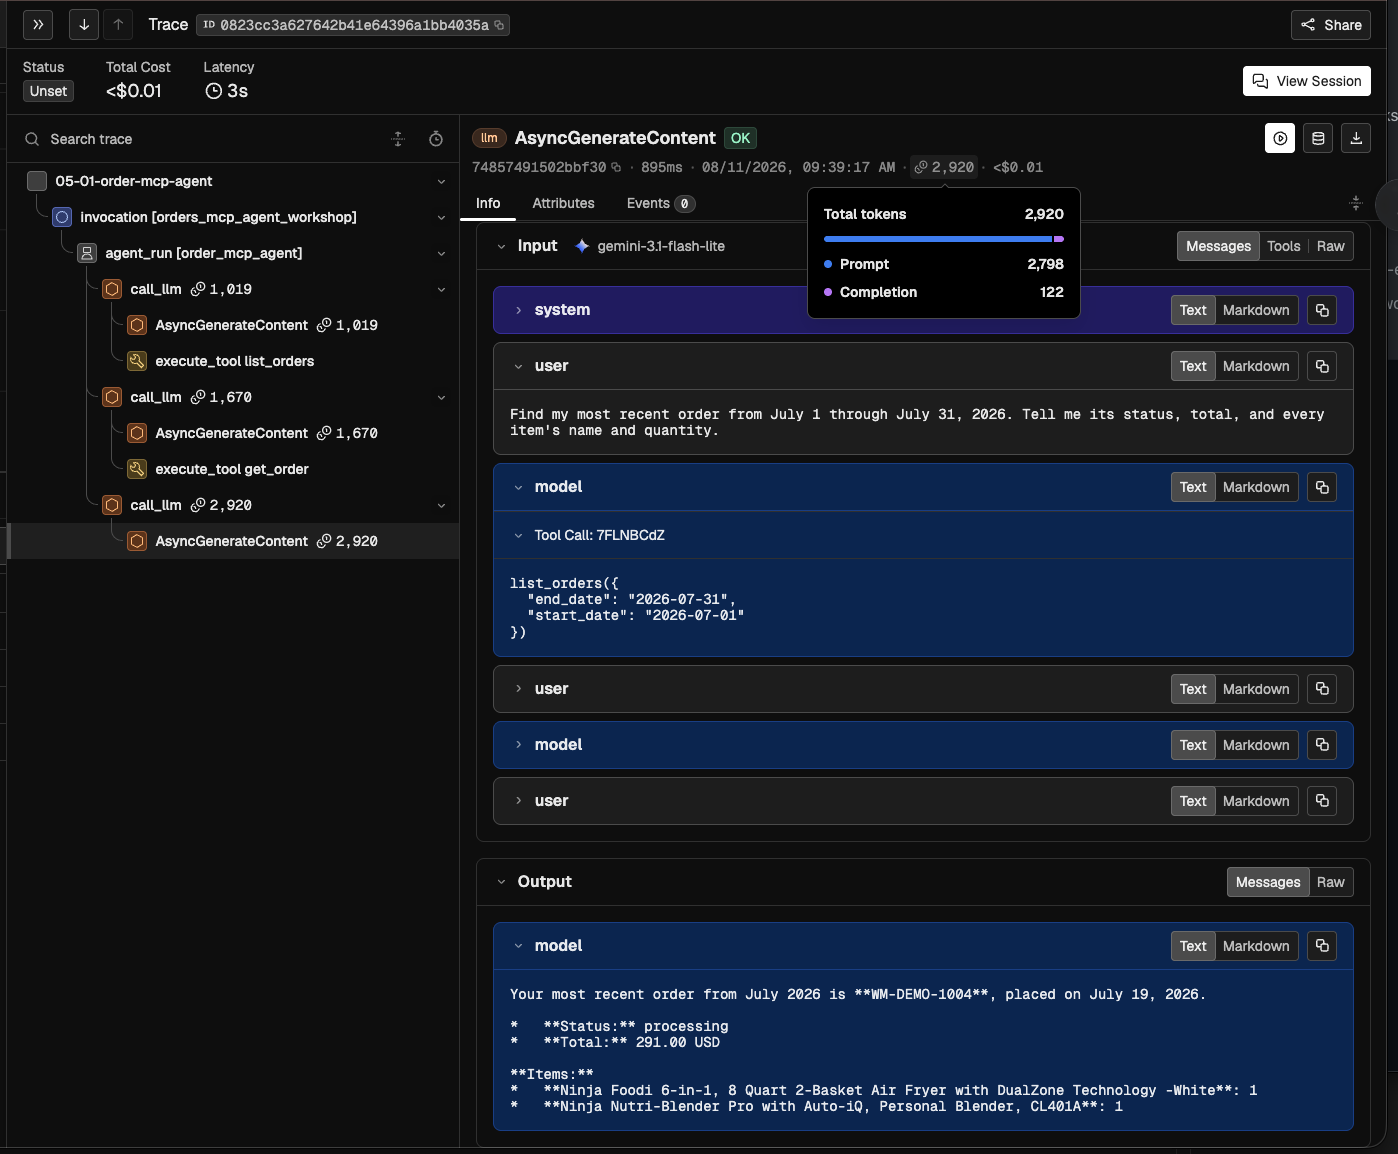

**What to notice**

The agent sees two remote tool schemas. Each returned result re-enters the agent context before the next decision.

**Takeaway:** MCP changes how tools are published and shared; it does not eliminate the model → tool → model loop.

#### 🔎 Direct MCP: verbose remote schemas

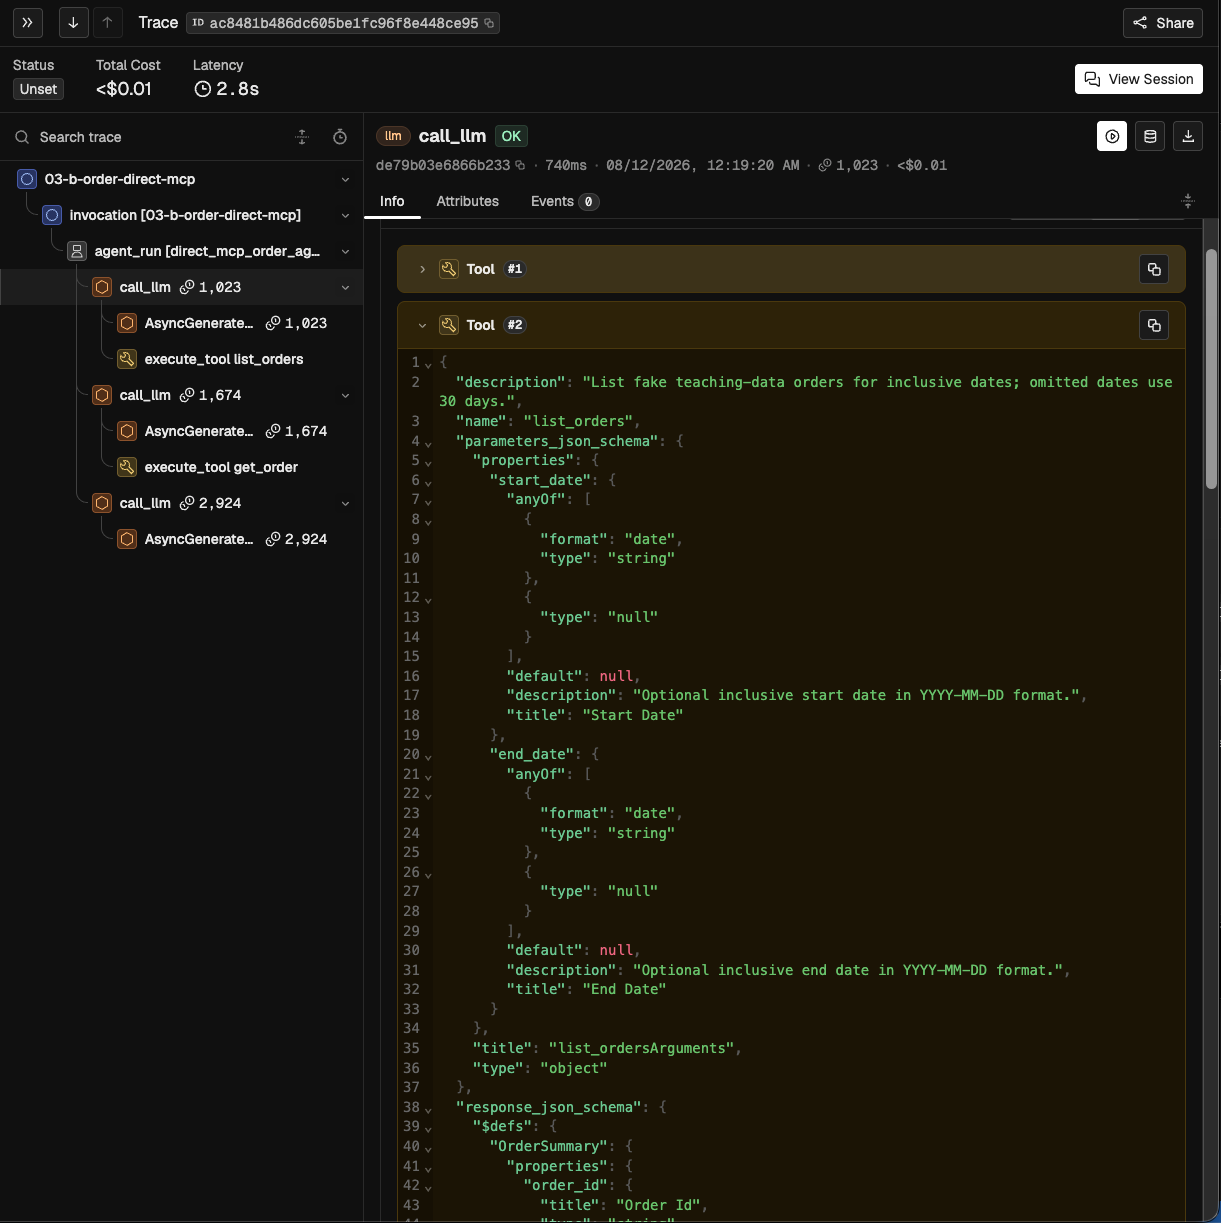

**What to notice**

The remote contract includes detailed parameter and response schemas. The answer uses the same three model calls and two tool calls, but the captured model calls grow to 1,023, 1,674, and 2,924 tokens because more schema text is carried in context.

**Takeaway:** A richer reusable contract can cost more prompt tokens even when the workflow and final answer stay the same.

**What changed?** The Local and Direct MCP agents perform the same work and
return the same grounded answer. In these captured traces, Local tools total
**2,073 model tokens**, while Direct MCP totals **5,621**. MCP is reusable
across clients; the trade-off here is that its richer remote schemas are more
verbose than the small local function definitions.

## 3 · MCP Code

The Code Mode server contains the full ecommerce catalog. This Order agent sees
only two standard Code Mode tools: `search` and `execute`.

1. Make **one detailed Order search** with the `orders` tag. It returns the names,
   descriptions, and schemas for just the matching Order tools.
2. Make **one bounded execution**. The generated program calls those discovered
   tools internally, and only its final result returns to the agent.

Product schemas stay out of this agent's active context because the search is
filtered by tag. This is a **discovery filter, not an authorization boundary**:
the model is instructed to use only the returned Order contracts. The underlying
tools remain registered normally on the FastMCP server; Code Mode handles
discovery and execution.

In [6]:
# Expose the standard discovery and bounded-execution tools.
order_code_tools = order_code_from_mcp()
show_source(order_code_from_mcp)

def order_code_from_mcp():                                                                                         
    """Discover detailed Order schemas, then run one bounded program."""                                           
                                                                                                                   
    from google.adk.tools.mcp_tool import (                                                                        
        McpToolset,                                                                                                
        StreamableHTTPConnectionParams,                                                                            
    )                                                                                                              
                                                                                                                   
    toolset = McpToolset(                                                                                          
        connection_params=StreamableHTTPConnectionParams(url=MCP_CODE_ENDPOINT),                                   
        tool_filter=["search", "execute"],                                                                         
    )                                                                                                              
    _active_toolsets.append(toolset)                                                                               
    return toolset

The ADK connection filters the Code Mode surface—not the server's full catalog:

```python
McpToolset(
    connection_params=StreamableHTTPConnectionParams(url=MCP_CODE_ENDPOINT),
    tool_filter=["search", "execute"],
)
```

In [7]:
CODE_EXECUTION_GUIDANCE = (
    'Discover the Order tools with one `search` call using tags=["orders"]. '
    "Solve the request with `execute`. Follow the discovered schemas exactly. "
    "Use only the discovered tools through `await call_tool(...)`. Return requested fields as one "
    "JSON-serializable result; never `print`."
)
CODE_INSTRUCTION = BASE_INSTRUCTION + " " + CODE_EXECUTION_GUIDANCE
show_text("MCP Code instruction", CODE_INSTRUCTION)

╭───────────────────────────────────────────── MCP Code instruction ──────────────────────────────────────────────╮
│ Help customers answer order questions using the available tools. Use only returned information, and clearly say │
│ when information is missing. Discover the Order tools with one `search` call using tags=["orders"]. Solve the   │
│ request with `execute`. Follow the discovered schemas exactly. Use only the discovered tools through `await     │
│ call_tool(...)`. Return requested fields as one JSON-serializable result; never `print`.                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [8]:
# Build an agent that sees only search and execute—not the catalog tools directly.
code_agent = Agent(
    name="order_code_agent",
    model=MODEL,
    instruction=CODE_INSTRUCTION,
    tools=[order_code_tools],
)
code_result = await run_agent(
    code_agent,
    ORDER_PROMPT,
    session_id="03-c-mcp-code",
    trace_name="03-c-order-mcp-code",
)
assert 2 <= code_result.tool_calls <= 3, (
    "MCP Code should use one search and one or two execute attempts."
)
assert code_result.tool_names[0] == "search"
assert all(name == "execute" for name in code_result.tool_names[1:])
search_arguments = code_result.tool_arguments[0]
assert search_arguments.get("query"), "Code Mode search needs a query."
assert search_arguments.get("tags") == ["orders"]

Your most recent order from July 2026 is order ID **WM-DEMO-1004**, placed on July 19, 2026.

*   **Status:** processing
*   **Total:** $291.00 USD

**Items:**
*   **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology -White**: 1
*   **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A**: 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/dacc9d56d961ec7e05a3aff665126f0c)

### Inspect the generated program

The second model call writes a short Python program and sends it as the
`code` argument to `execute`. This is model-generated code—not handwritten
notebook code. We render the final execution attempt below so it is easy to
read outside Phoenix too.

In [9]:
# Extract the exact Python program the model sent to execute.
generated_programs = [
    arguments["code"]
    for tool_name, arguments in zip(
        code_result.tool_names,
        code_result.tool_arguments,
    )
    if tool_name == "execute" and isinstance(arguments.get("code"), str)
]
assert generated_programs, "MCP Code did not produce an execution program."
show_text("Generated Python sent to execute", generated_programs[-1])

╭─────────────────────────────── Generated Python sent to execute ────────────────────────────────╮
│ orders = await call_tool("list_orders", {"start_date": "2026-07-01", "end_date": "2026-07-31"}) │
│ if not orders["result"]:                                                                        │
│     result = "No orders found for the specified period."                                        │
│ else:                                                                                           │
│     # Sort by date                                                                              │
│     sorted_orders = sorted(orders["result"], key=lambda x: x["order_date"], reverse=True)       │
│     recent_order_id = sorted_orders[0]["order_id"]                                              │
│     details = await call_tool("get_order", {"order_id": recent_order_id})                       │
│     result = details                                                                            │
│                                                                                                 │
│ return result                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────╯

#### 🔎 MCP Code trace: search, then generated execution

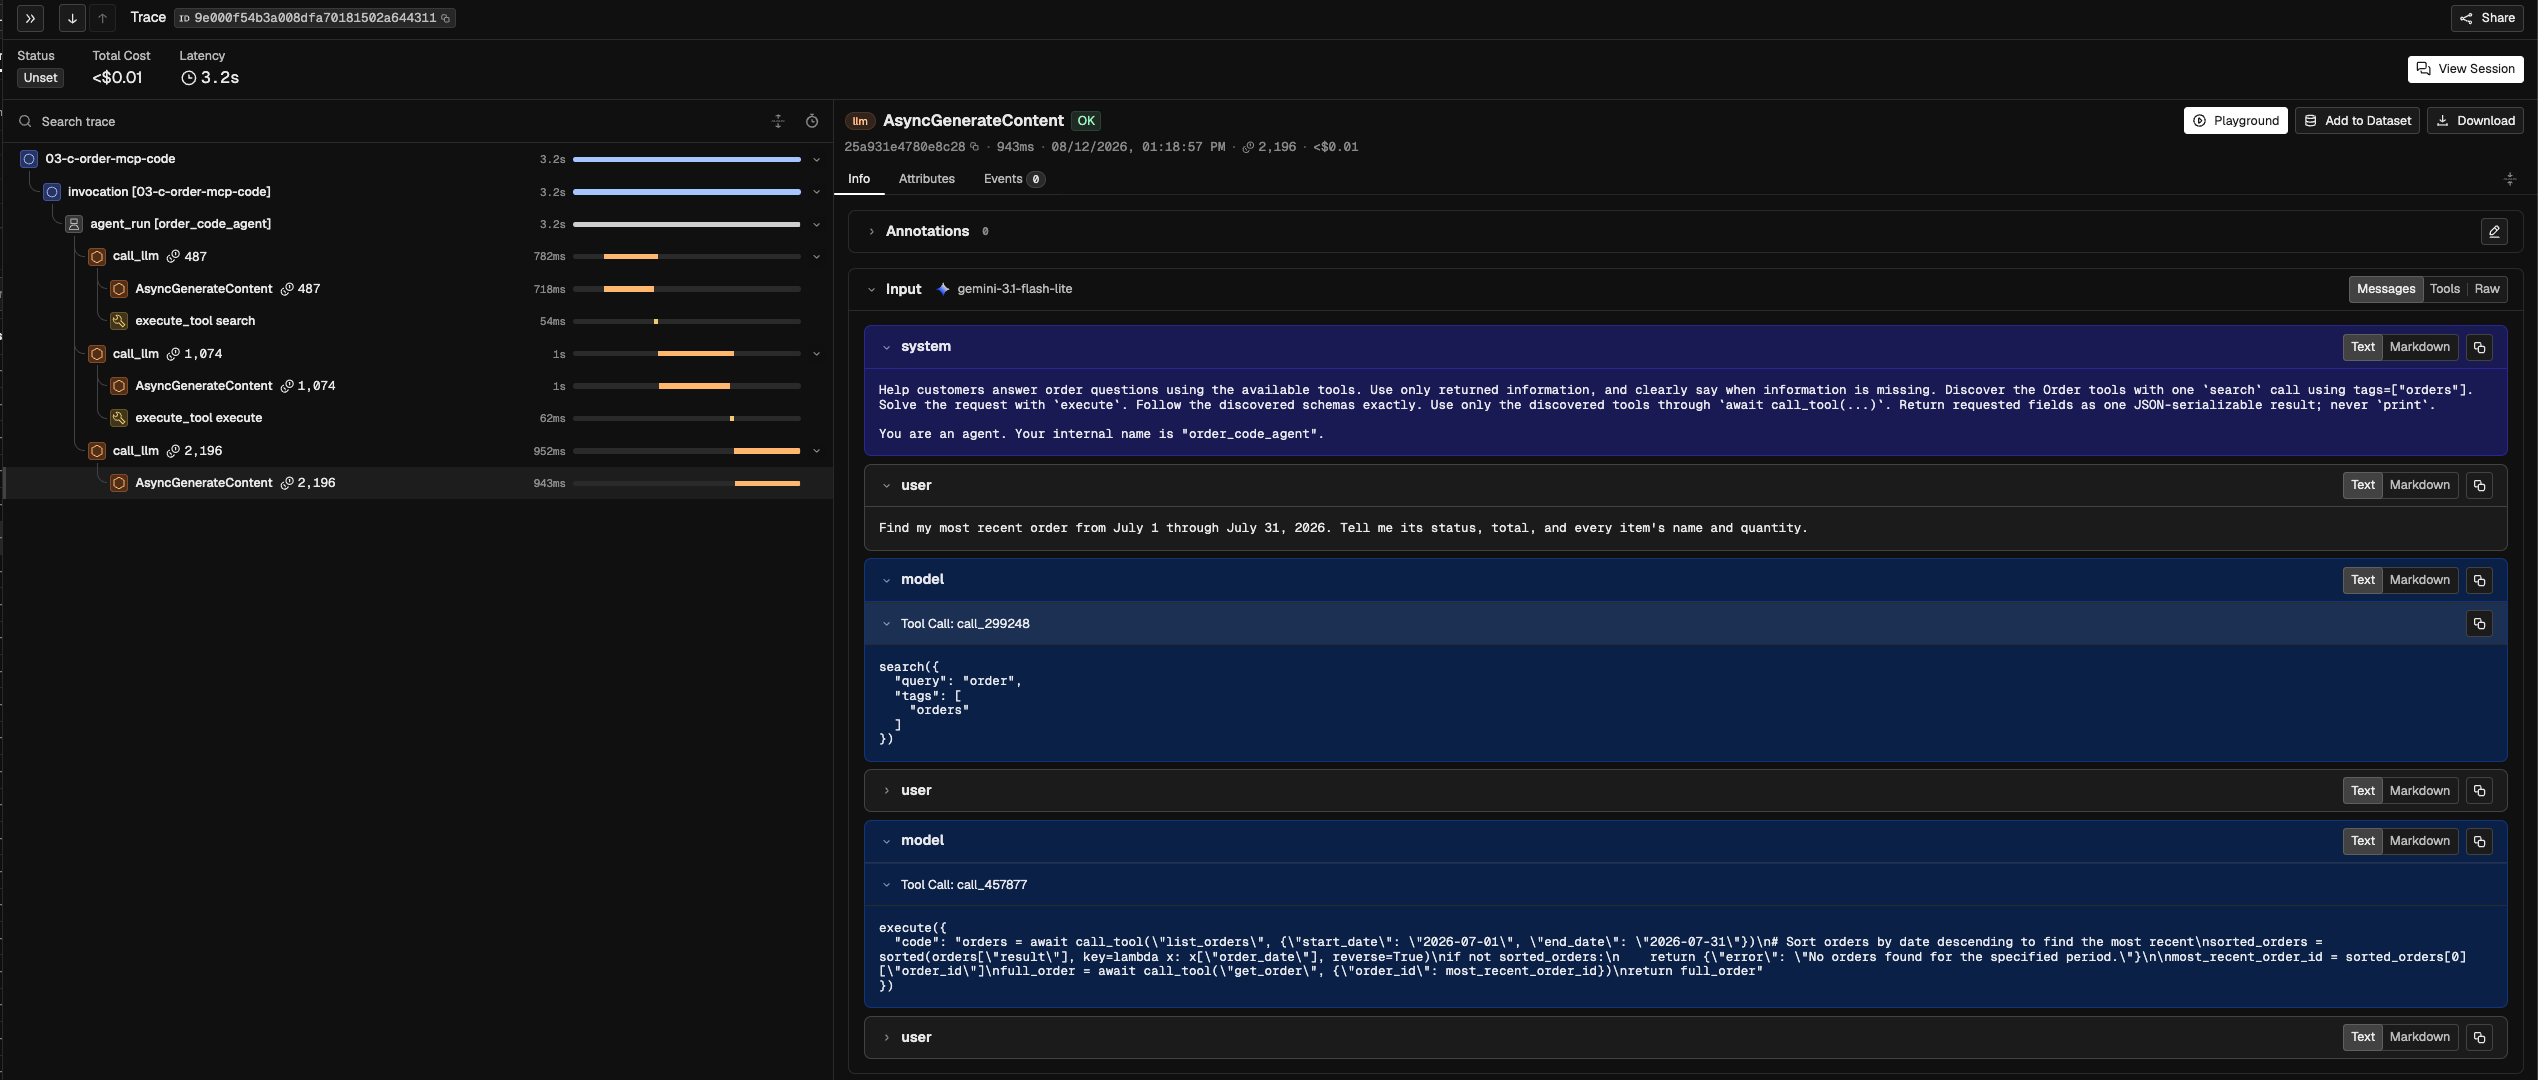

**What to notice**

The trace has three model calls and two visible MCP tool calls. The first model call requests a tagged `search`; the second writes the Python program rendered above and sends it to `execute`; the third turns the projected JSON result into the customer answer. The captured model calls report 487, 1,074, and 2,196 total tokens.

**Takeaway:** Code Mode keeps the generated multi-tool workflow inside one bounded execution, while the agent conversation sees discovery and the final projected result.

#### 🔎 MCP Code tools and grounded answer

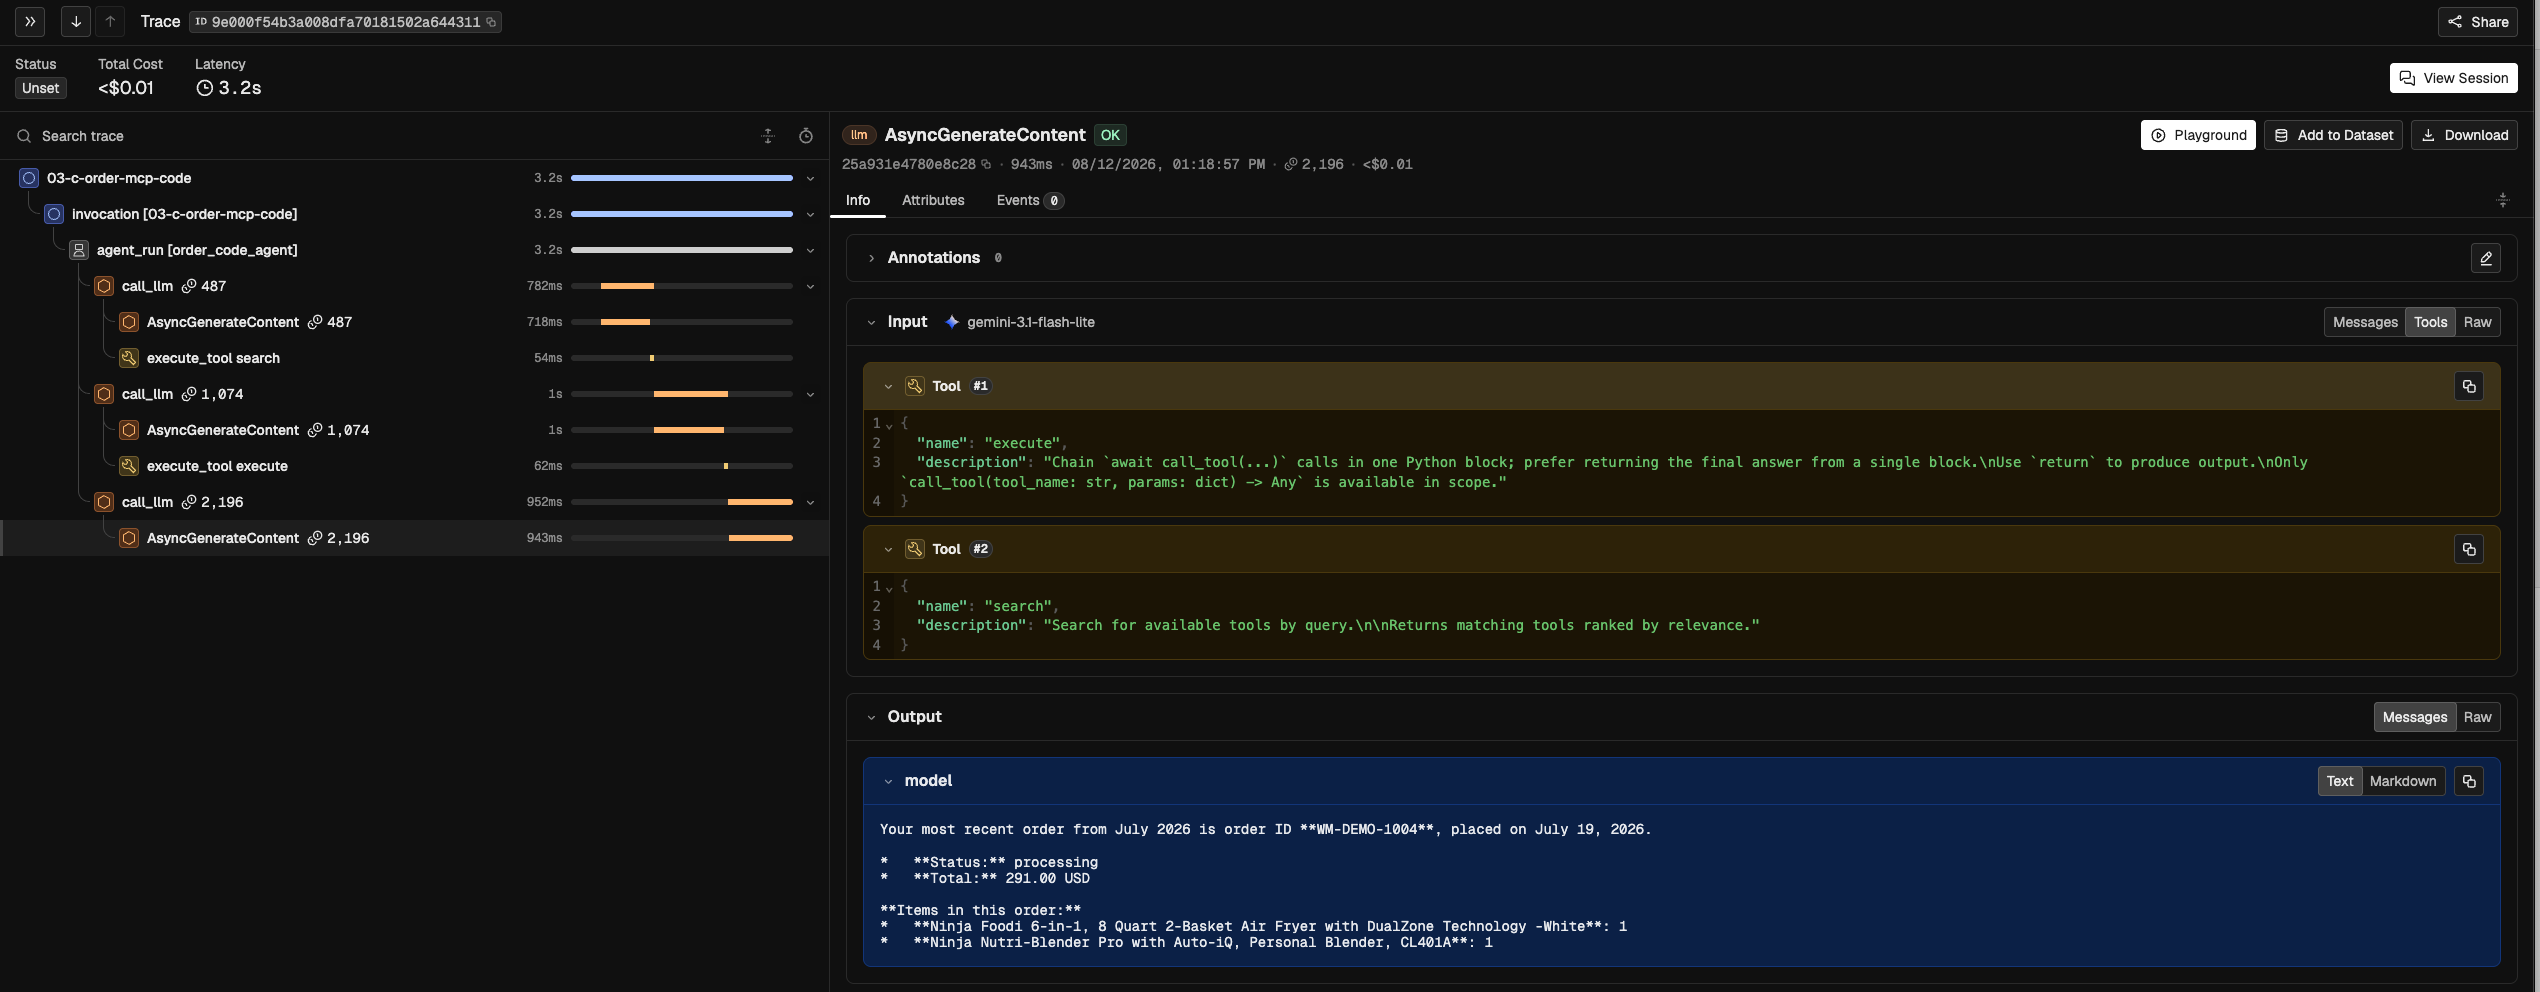

**What to notice**

The agent-facing tool list contains only the standard `search` and `execute` contracts. The Order tools remain ordinary registered server tools, but their detailed contracts arrive only through the tagged search. The final response still contains the requested status, total, item names, and quantities.

**Takeaway:** The model needs a small stable Code Mode interface; it does not need every ecommerce tool schema loaded before the request begins.

#### 🔎 MCP Code architecture: discover, then execute



**What to notice**

The first visible call searches the full catalog by the `orders` tag and returns detailed contracts for `list_orders` and `get_order`. The second visible call runs one bounded program; intermediate summaries and full order details stay inside execution, while only the final projected result enters the agent conversation.

**Takeaway:** Observe the context boundary: the agent receives the discovery result and the final projected result—not every ecommerce schema or every intermediate payload. Tag filtering focuses discovery; it is not a security allowlist.

## 4 · MCP + Skill

A Skill adds a reusable procedure for ecommerce shopping orders. If the user
supplies an order ID, call `get_order` directly; otherwise it can
discover the right ID, inspect details, and stay grounded. The agent loads
that guidance when it needs it.

In [10]:
# Load the reusable procedures for the Order workflow.
order_skill = load_skill_from_dir(ORDER_SKILL.parent)
show_skill(ORDER_SKILL)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                  Order support                                                  ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

Use the activated order tools to answer factual questions about synthetic ecommerce shopping orders.               


                                                     Procedure                                                     

 1 If the user supplies an order ID, call get_order directly. Do not list unrelated orders first.                  
 2 If the order ID is unknown, convert any requested period into explicit, inclusive YYYY-MM-DD start and end      
   dates.                                                                                                          
 3 Call list_orders only when discovery or date filtering is needed. Select order IDs only from its returned       
   summaries.                                                                                                      
 4 When the user asks for the most recent order, compare only the returned order dates and select the newest one in
   the requested period.                                                                                           
 5 Call get_order for the selected order before reporting item names, quantities, or other detail-only fields.     
 6 Base status, date, total, and item claims only on returned fields. Clearly identify missing fields.             
 7 If a tool returns an error or no matching orders, report that result plainly and stop.                          


                                                  Grounding rules                                                  

 • Never invent an order ID, date, status, total, item, quantity, or delivery fact.                                
 • Do not treat an order summary as the full order record.                                                         
 • Do not guess a wider date range or substitute a different order after an error.

In [11]:
# Activate only the tools that the Skill may call.
skill_order_tools = order_tools_from_mcp()

# Combine procedural guidance with the focused MCP tools.
order_skill_toolset = SkillToolset(
    skills=[order_skill],
    additional_tools=[skill_order_tools],
)

In [12]:
# Give the agent reusable guidance that it can load on demand.
skill_agent = Agent(
    name="skill_order_agent",
    model=MODEL,
    instruction=BASE_INSTRUCTION,
    tools=[order_skill_toolset],
)

In [13]:
# Run the same request through the Skill design.
skill_result = await run_agent(
    skill_agent,
    ORDER_PROMPT,
    session_id="03-d-order-skill",
    trace_name="03-d-order-skill",
)

Your most recent order between July 1 and July 31, 2026, is order **WM-DEMO-1004**, placed on July 19, 2026.

*   **Status:** processing
*   **Total:** $291.00 USD

**Items in this order:**
*   **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology -White:** 1
*   **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A:** 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/c2d744093c8c82e94877d7498e1c3a12)

#### 🔎 Skill: complete workflow

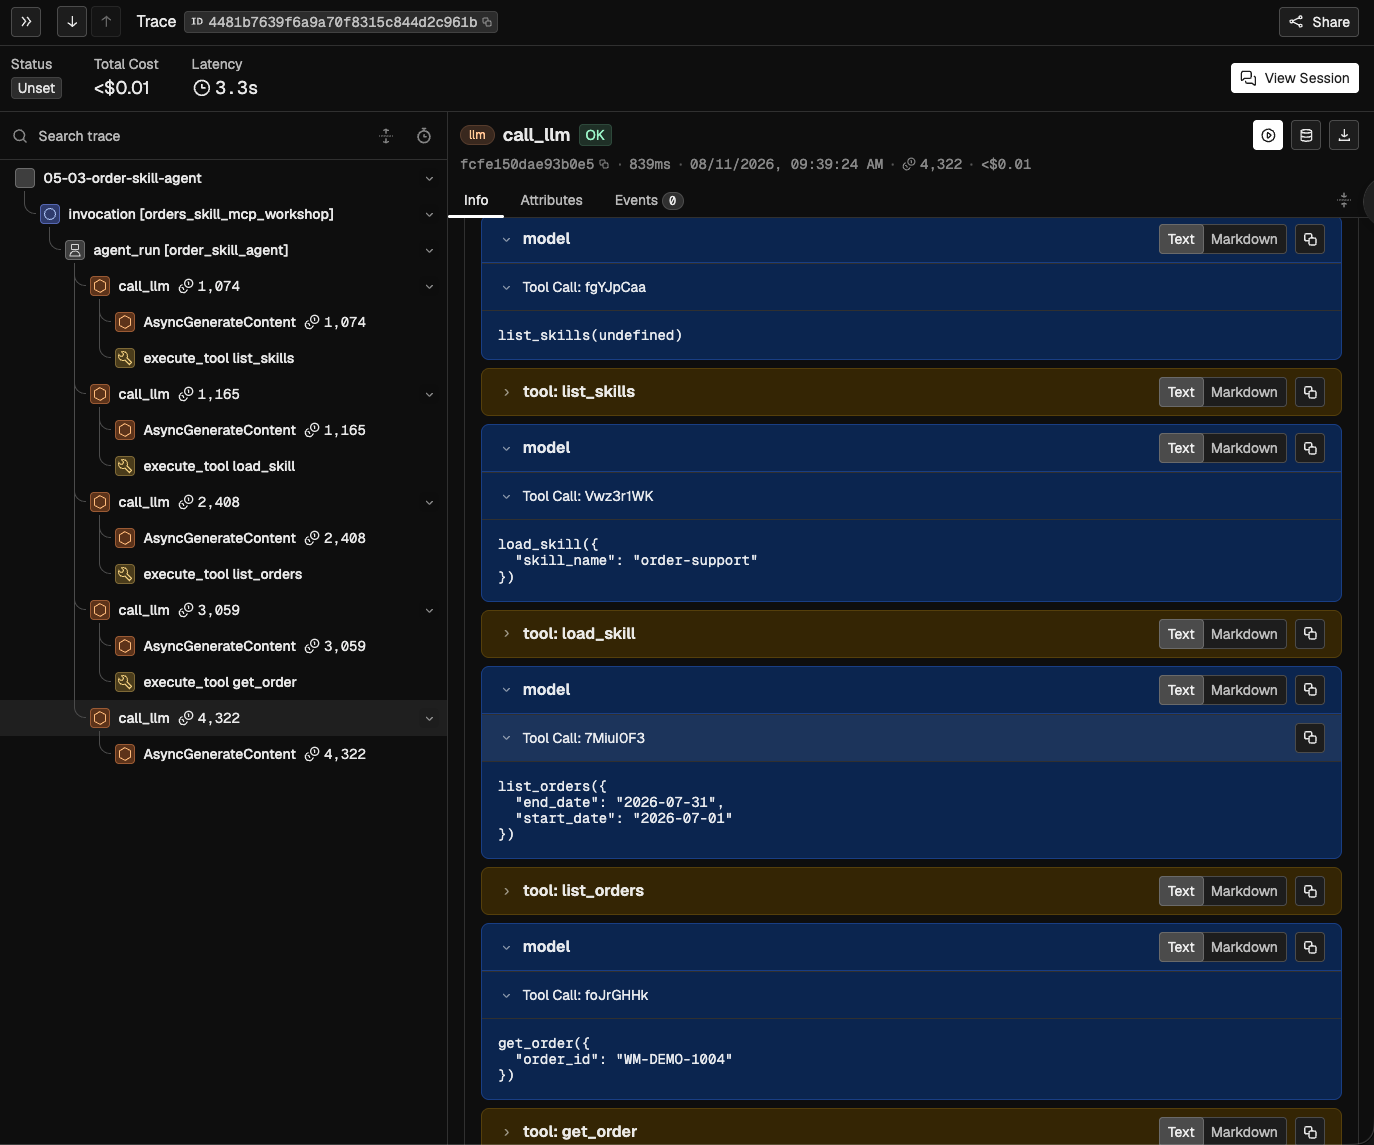

**What to notice**

The trace adds discovery and loading before the familiar Order workflow. Those initial model turns explain why this captured run uses more tokens up front.

**Takeaway:** Skills trade extra discovery and loading turns for reusable guidance that can be selected on demand.

#### 🔎 Skill: lightweight bootstrap tools

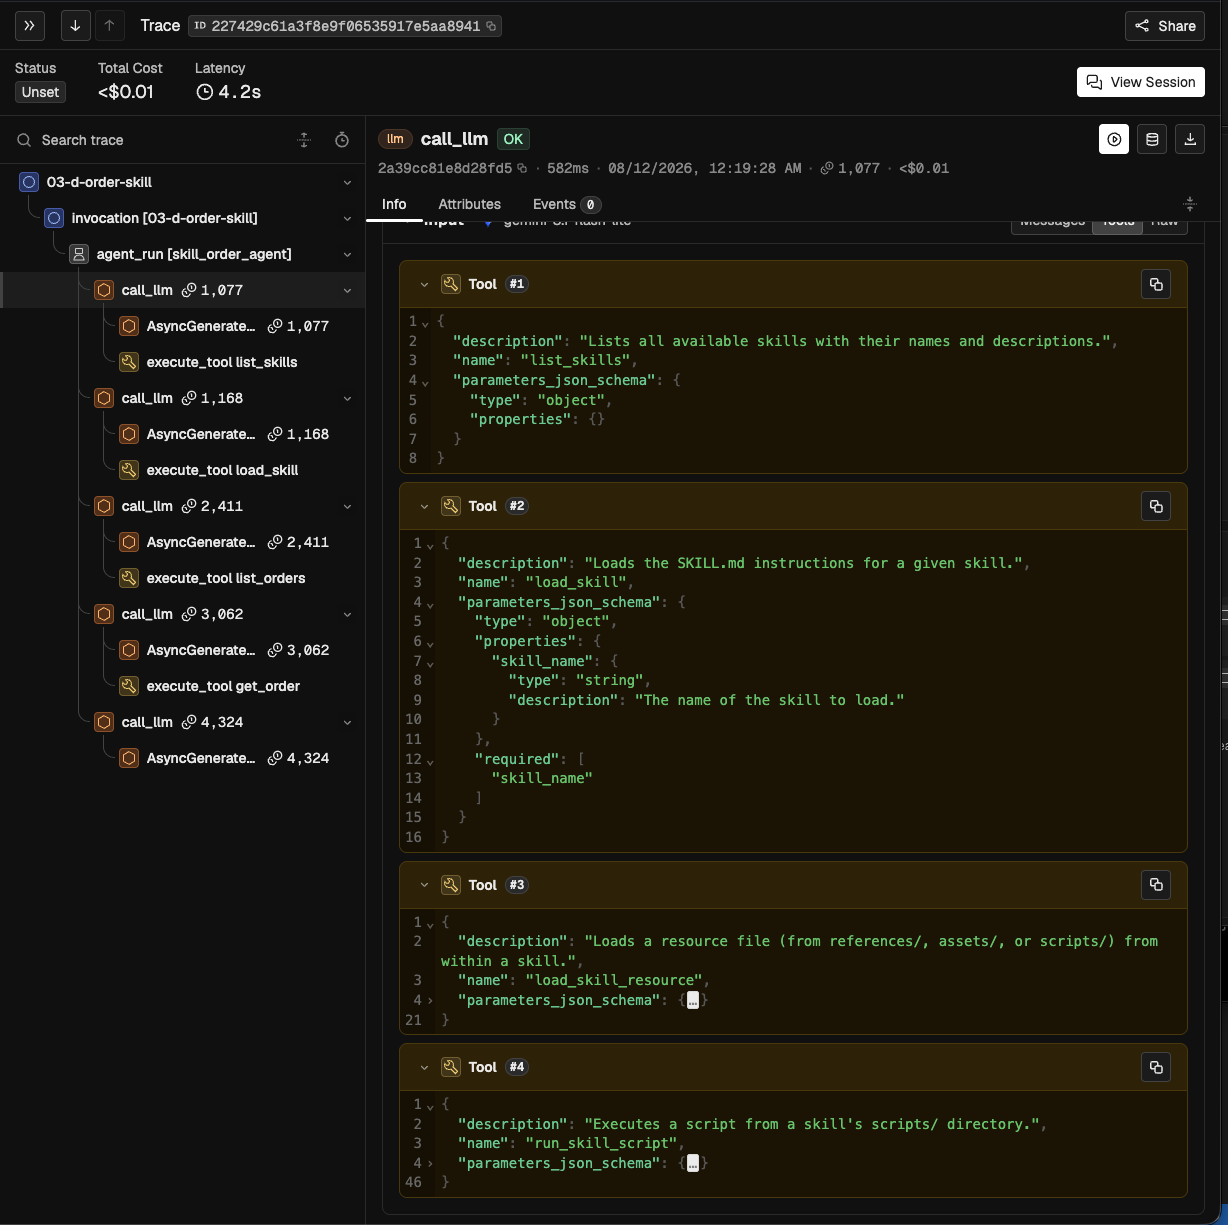

**What to notice**

Before a Skill is selected, the model sees generic Skill tools such as `list_skills`, `load_skill`, resource loading, and script execution—not every domain tool.

**Takeaway:** Skill discovery begins with a small generic interface instead of loading every domain procedure immediately.

#### 🔎 Skill: exact Order tools after loading

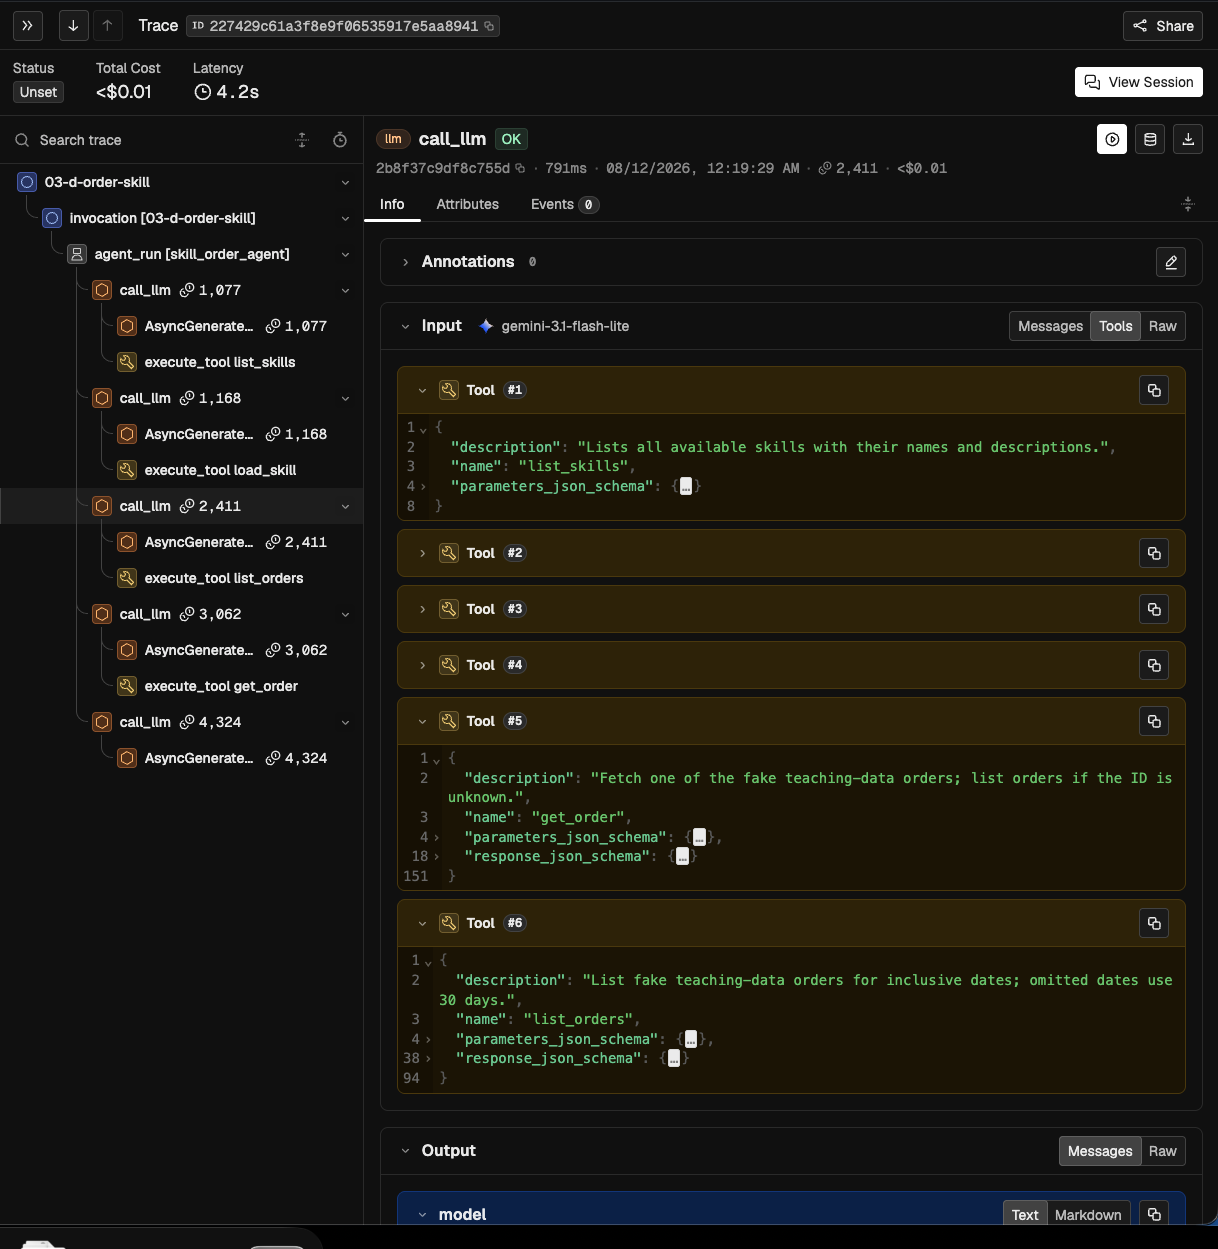

**What to notice**

After `order-support` is loaded, the exact Order tools `list_orders` and `get_order` join the generic Skill tools. The initial discovery turns produce higher token counts in the early turns, then the loaded procedure guides the normal list-then-detail workflow.

**Takeaway:** Loading a Skill adds its detailed guidance and exact tools only when the current request needs that domain.

## 🔎 Comparison

In [14]:
# Compare the learner-useful signals from all four runs.
show_comparison([
    {
        "Approach": "Local tools", "Visible tools": 2,
        "Model calls": local_result.model_calls,
        "Tool calls": local_result.tool_calls,
        "Tokens": local_result.tokens,
        "Latency": local_result.latency_seconds,
    },
    {
        "Approach": "Direct MCP", "Visible tools": 2,
        "Model calls": direct_mcp_result.model_calls,
        "Tool calls": direct_mcp_result.tool_calls,
        "Tokens": direct_mcp_result.tokens,
        "Latency": direct_mcp_result.latency_seconds,
    },
    {
        "Approach": "MCP Code", "Visible tools": 2,
        "Model calls": code_result.model_calls,
        "Tool calls": code_result.tool_calls,
        "Tokens": code_result.tokens,
        "Latency": code_result.latency_seconds,
    },
    {
        "Approach": "MCP + Skill", "Visible tools": "On demand",
        "Model calls": skill_result.model_calls,
        "Tool calls": skill_result.tool_calls,
        "Tokens": skill_result.tokens,
        "Latency": skill_result.latency_seconds,
    },
])

┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Approach    ┃ Visible tools ┃ Model calls ┃ Tool calls ┃ Tokens ┃ Latency ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ Local tools │ 2             │ 3           │ 2          │ 2073   │ 2.69    │
│ Direct MCP  │ 2             │ 3           │ 2          │ 5606   │ 3.04    │
│ MCP Code    │ 2             │ 4           │ 3          │ 5241   │ 4.35    │
│ MCP + Skill │ On demand     │ 5           │ 4          │ 12145  │ 4.53    │
└─────────────┴───────────────┴─────────────┴────────────┴────────┴─────────┘

## Conclusion

- **Local tools** are easy to start with, but each client owns the wrapper.
- **Direct MCP** makes capabilities reusable across clients.
- **MCP Code** discovers focused schemas, then keeps intermediate multi-tool work bounded.
- **Skills** package reusable guidance and load it when needed.

## ✅ Checkpoint

You compared four real designs with one fair request. There is no universal
winner—the useful question is which design keeps the current job clearest.

## 🔎 Trace-reading prompt

Across the four implementations, compare the **LLM/tool boundaries**, how
**tool schemas in context** shape each trace, and the **total tokens**. What
changes, and what stays constant?

In [15]:
await close_mcp_tools()
print("✅ MCP connections closed cleanly")

✅ MCP connections closed cleanly
